<a href="https://colab.research.google.com/github/fabiocf12/MPA-MLF-exercises/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
import tensorflow as tf
import matplotlib.pyplot as plt


In [51]:
X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y = [0, 1, 1, 0]

In [52]:
model = Sequential()
model.add(InputLayer(input_shape=(2,)))
model.add(Dense(2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [53]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [54]:
import numpy as np
X = np.array(X)
y = np.array(y)
history = model.fit(X, y, epochs=3000, batch_size=1, verbose=0)

In [55]:
loss, accuracy = model.evaluate(X, y, verbose=0)
print('Accuracy: {:.2f}'.format(accuracy*100))

Accuracy: 100.00


In [56]:
for id_x, data_sample in enumerate(X):
  prediction = model.predict(np.expand_dims(data_sample, axis=0))
  print(f"Data sample is {data_sample}, prediction from model {prediction}, ground_truth {y[id_x]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Data sample is [0 0], prediction from model [[0.02343929]], ground_truth 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Data sample is [0 1], prediction from model [[0.9755923]], ground_truth 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Data sample is [1 0], prediction from model [[0.97328776]], ground_truth 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Data sample is [1 1], prediction from model [[0.02016162]], ground_truth 0


Text(0, 0.5, 'loss')

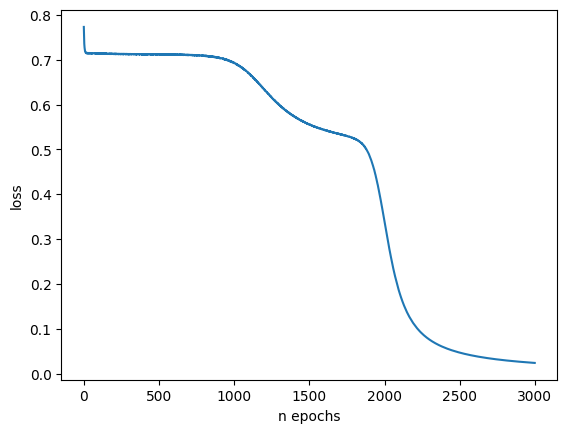

In [57]:
plt.figure()
plt.plot(history.history['loss'])
plt.xlabel('n epochs')
plt.ylabel('loss')

In [58]:
#EXERCISE 2

import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive to access files
drive.mount('/content/drive')

path_to_dataset = 'drive/MyDrive/MPA-MLF/EX_5/voting_complete.csv' # change the PATH
pd_dataset = pd.read_csv(path_to_dataset)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
pd_dataset

,Unnamed: 0,Class Name,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,0,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,3,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,4,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,430,republican,n,n,y,y,y,y,n,n,y,y,n,y,y,y,n,y
431,431,democrat,n,n,y,n,n,n,y,y,y,y,n,n,n,n,n,y
432,432,republican,n,?,n,y,y,y,n,n,n,n,y,y,y,y,n,y
433,433,republican,n,n,n,y,y,y,?,?,?,?,n,y,y,y,n,y


In [60]:
# define a function for train and test split

def train_test_split(pd_data: pd.DataFrame, test_ratio: float = 0.2) -> tuple:
    pd_dataset = pd_data.copy()
    pd_dataset = pd_dataset[pd_dataset.columns[1:]]
    index = np.arange(len(pd_dataset))
    index = np.random.permutation(index)
    train_ammount = int(len(index)*test_ratio)
    train_ids = index[train_ammount:]
    test_ids = index[:train_ammount]

    train_dataset = pd_dataset[pd_dataset.index.isin(train_ids)].reset_index()
    test_dataset = pd_dataset[pd_dataset.index.isin(test_ids)].reset_index()

    train_dataset = train_dataset[train_dataset.columns[1:]]
    test_dataset = test_dataset[test_dataset.columns[1:]]

    return train_dataset[train_dataset.columns[1:]], train_dataset[train_dataset.columns[0]], test_dataset[test_dataset.columns[1:]], test_dataset[test_dataset.columns[0]]


In [61]:
x_train, y_train, x_test, y_test = train_test_split(pd_dataset)

In [62]:
# 3.
"""
1. Classification  ( binary classification (2 classes) )
2. 435
3. 16
4. All the features and labels are categorical/string data types (represented as object in pandas)
5. Yes
6. 2 republican /democrat
"""

'\n1. Classification  ( binary classification (2 classes) )\n2. 435\n3. 16\n4. All the features and labels are categorical/string data types (represented as object in pandas)\n5. Yes\n6. 2 republican /democrat\n'

In [63]:
# 4. Data preprocessing

# a) Replace missing values with any data imputation technique ( for example, the most occurring value in the column), then perform one-hot encoding or label encoding of your data

# mapping and converting the labels to values ( label encoding)
label_mapping = {"democrat" : 1 , "republican": 0}
y_train_encoded = y_train.map(label_mapping).astype("float32")
y_test_encoded = y_test.map(label_mapping).astype("float32")

# change the ? to Nan so that pandas recognizes as null value
x_train_imputed = x_train.replace("?", np.nan)
x_test_imputed = x_test.replace("?", np.nan)

# replace null values with most common value in collumn

for i in x_train_imputed.columns:
  most_common_value = x_train_imputed[i].mode()[0] # gets the most common value of column i

  x_train_imputed[i] = x_train_imputed[i].fillna(most_common_value) # replace Nan by the value
  x_test_imputed[i] = x_test_imputed[i].fillna(most_common_value)


# replacing on features
feature_mapping = {"y":1.0,"n":0.0}
x_train_encoded = x_train_imputed.replace(feature_mapping).astype("float32")
x_test_encoded = x_test_imputed.replace(feature_mapping).astype("float32")


/tmp/ipykernel_62444/903368967.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_train_encoded = x_train_imputed.replace(feature_mapping).astype("float32")
/tmp/ipykernel_62444/903368967.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_test_encoded = x_test_imputed.replace(feature_mapping).astype("float32")


In [64]:
# b) Consider the missing value to be the third category 'unknown' and then perform one-hot encoding or label encoding

# encode the labels
label_mapping = {'democrat': 1, 'republican': 0}
y_train_encoded = y_train.map(label_mapping).astype('float32')
y_test_encoded = y_test.map(label_mapping).astype('float32')

# 2. Label Encoding with 3 categories (n = 0, y = 1, ? = 2)

feature_mapping_3_categories = {'n': 0.0, 'y': 1.0, '?': 2.0}

x_train_encoded = x_train.replace(feature_mapping_3_categories).astype('float32')
x_test_encoded = x_test.replace(feature_mapping_3_categories).astype('float32')


/tmp/ipykernel_62444/1783574760.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_train_encoded = x_train.replace(feature_mapping_3_categories).astype('float32')
/tmp/ipykernel_62444/1783574760.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_test_encoded = x_test.replace(feature_mapping_3_categories).astype('float32')


In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import SGD # Stochastic Gradient Descent

# Create your model using atleast one hidden layer.
model = Sequential()

# hidden layer: 8 neurons and relu activation
# input_shape=(16,) meaning that will enter 16 columns (our features)
model.add(Dense(8, input_shape=(16,), activation='relu'))

# output layer: 1 single neuron with activation  'sigmoid' (returns value between 0 and 1)
model.add(Dense(1, activation='sigmoid'))


# Check what model.summary() does
model.summary()

# Compile the model
# Gradient Descent (SGD) and learning_rate
optimizer = SGD(learning_rate=0.01)

# Compile with function for binary classification
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(x_train_encoded,
                    y_train_encoded,
                    epochs=100,
                    batch_size=16,
                    validation_data=(x_test_encoded, y_test_encoded))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6524 - loss: 0.6424 - val_accuracy: 0.5977 - val_loss: 0.6305
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7267 - loss: 0.6015 - val_accuracy: 0.6782 - val_loss: 0.5869
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7686 - loss: 0.5672 - val_accuracy: 0.7471 - val_loss: 0.5475
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8020 - loss: 0.5116 - val_accuracy: 0.7816 - val_loss: 0.5151
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7835 - loss: 0.5160 - val_accuracy: 0.7931 - val_loss: 0.4878
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8144 - loss: 0.4751 - val_accuracy: 0.7931 - val_loss: 0.4646
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8305 - loss: 0.4492 - val_accuracy: 0.8161 - val_loss: 0.4451
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8783 - loss: 0.3899 - val_accuracy: 0.8161 - 

In [66]:
# 7. Model Evaluation

#Preprocessing done on test previously already


# Evaluate the model, print final accuracy and loss
loss, accuracy = model.evaluate(x_test_encoded, y_test_encoded, verbose=0)
print(f"Loss (Margem de Erro): {loss:.4f}")
print('Accuracy: {:.2f}'.format(accuracy*100))

Loss (Margem de Erro): 0.1886
Accuracy: 89.66


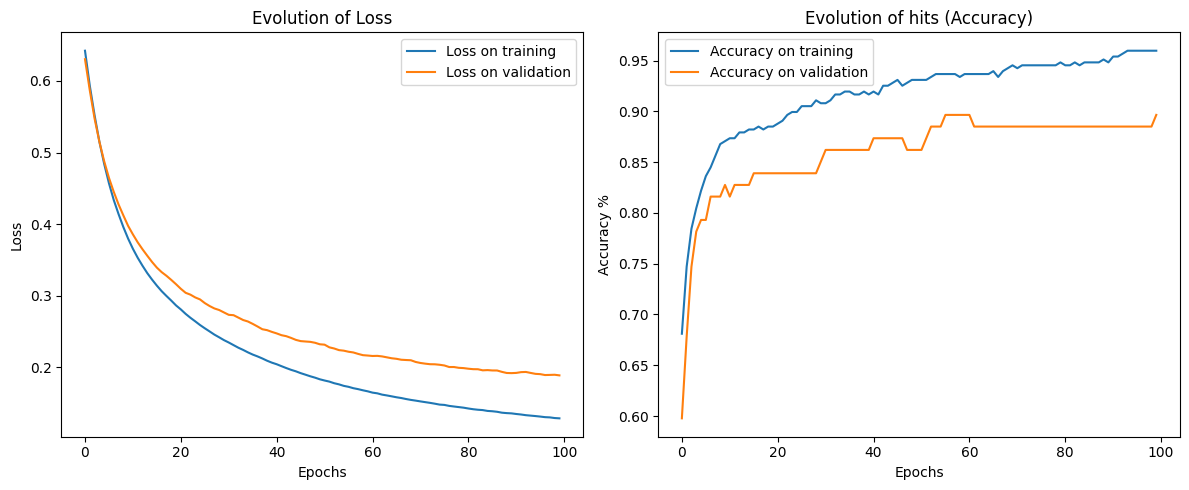

In [67]:
# Plot loss and validation loss depending on the training epochs into one graph. In another graph, plot accuracy and validation accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

#Graph 1
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"] ,label ="Loss on training")
plt.plot(history.history["val_loss"] ,label ="Loss on validation")
plt.title('Evolution of Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

#Graph 2
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"] ,label ="Accuracy on training")
plt.plot(history.history["val_accuracy"] ,label ="Accuracy on validation")
plt.title('Evolution of hits (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy %')
plt.legend()

plt.tight_layout()
plt.show()
